In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("dataset/df_final_agritech.csv")
df.shape

(64368, 24)

### EDA data engineering

In [3]:
# supression de tous les item sans yield
df = df.loc[~(df['Value'].isna()),:]
df.shape

(55141, 24)

In [4]:
# supression de la colonne Year pour passer en données non temporelles :
del_column = ['Year']
df = df.drop(columns=del_column)
df.shape

(55141, 23)

In [5]:
# supression de la colonne Element qui est catégorielle et avec une seul classe -> 'Yield'
del_column = ['Element']
df = df.drop(columns=del_column)
df.shape

(55141, 22)

In [6]:
# on ne garde que les lignes avec l'unité 'kg/ha'
df = df.loc[(df['Unit']=='kg/ha'),:]

# supression de la colonne Unit qui est catégorielle et avec une seul classe -> 'kg/ha'
del_column = ['Unit']
df = df.drop(columns=del_column)
df.shape

(54235, 21)

In [7]:
# supression des colonnes climatiques

del_column = ['cld_mean_pct', 'pre_total_mm',
       'tmp_mean_c', 'wet_days_total', 'frost_days_total', 'pet_total_mm',
       'diurnal_range_mean_c', 'tmp_max_mean_c', 'tmp_min_mean_c',
       'vap_pressure_mean_hpa']
df = df.drop(columns=del_column)
df.shape

(54235, 11)

### attention supression de toutes les lignes pour lesquelles une colonne est vide !

In [8]:
# attention supression de toutes les lignes pour lesquelles une colonne est vide !
df_propre= df.dropna()
df_propre.shape

(46956, 11)

### Suppression des Items qui sont des groupes , donc celles contenant les libellés ['primary','total','other']

In [9]:

#Suppression des Items qui sont des groupes , donc celles contenant les libellés ['primary','total','other']
item_importance = df_propre.groupby('Item')['Item'].count().sort_values(ascending=False)
print(len(item_importance))
df_propre = df_propre[
    ~df_propre['Item'].str.contains('primary', case=False, na=False) 
    & ~df_propre['Item'].str.contains('total', case=False, na=False)
    & ~df_propre['Item'].str.contains('other', case=False, na=False)
    ]
df_propre.shape
item_importance = df_propre.groupby('Item')['Item'].count().sort_values(ascending=False)
print(len(item_importance))

129
107


### Supression des outliers par la méthode de l'IQR (Tukey), quantile

In [10]:
Q1 = df_propre['Value'].quantile(0.25)
Q3 = df_propre['Value'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_propre = df_propre[(df_propre['Value'] >= lower) & (df_propre['Value'] <= upper)]
df_propre.shape


(33788, 11)

### section épurer les Items, maximum 60 Items

In [11]:
# on groupe chaque item par leur nombre d'occurences 
item_importance = df_propre.groupby('Item')['Item'].count().sort_values(ascending=False)

#on garde les 60 premières Items 
filtre_item = item_importance.head(60).index
df_propre = df_propre.loc[df_propre['Item'].isin(filtre_item), :]
df_propre.shape

print(len(item_importance))
print(len(df_propre.groupby('Item')['Item'].count().sort_values(ascending=False)))

106
60


In [12]:
df_propre.groupby('Item')['Item'].count().sort_values(ascending=False)

Item
Barley                                                          754
Wheat                                                           745
Oats                                                            727
Rye                                                             721
Cauliflowers and broccoli                                       701
Peas, green                                                     697
Strawberries                                                    673
Rape or colza seed                                              661
Peas, dry                                                       655
Raspberries                                                     652
Plums and sloes                                                 651
Cherries                                                        633
Pears                                                           633
Potatoes                                                        614
Oilcrops, Oil Equivalent                   

In [13]:
#df_propre.to_csv("./dataset/df_EDA_agritech.csv", index=False)

### EDA graphique

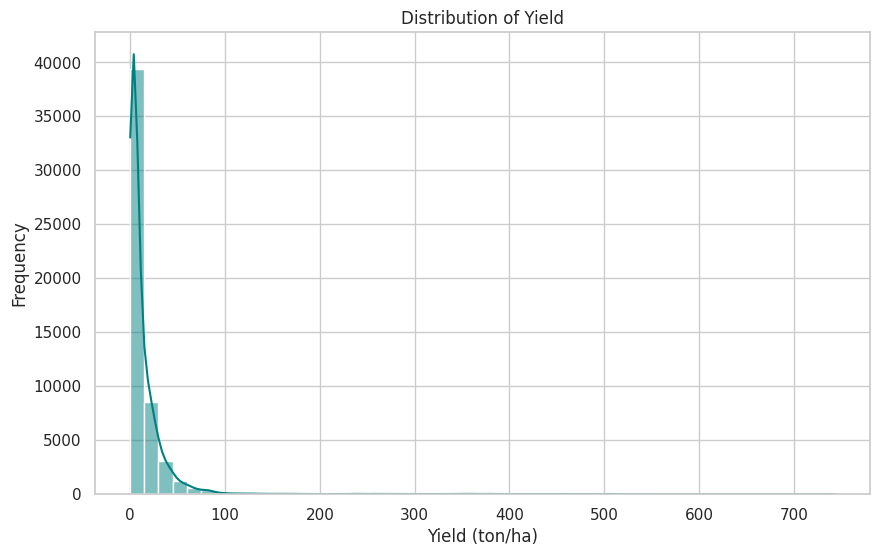

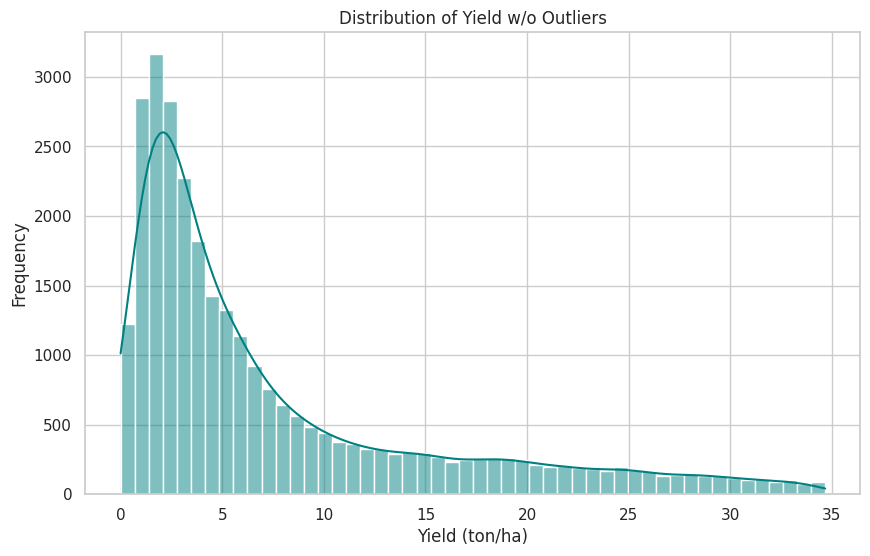

In [14]:
df_outliers =  df_propre
# Changement d'unité => kg/ha --> ton/ha
df["Value"] = df["Value"] / 1000

# Histogramme de 'Value'
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,6))
sns.histplot(df["Value"], bins=50, kde=True, color='teal')
plt.title("Distribution of Yield")
plt.xlabel("Yield (ton/ha)")
plt.ylabel("Frequency")
plt.show()


# Changement d'unité => kg/ha --> ton/ha
df_outliers["Value"] = df_outliers["Value"] / 1000

# Histogramme de 'Value'
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,6))
sns.histplot(df_outliers["Value"], bins=50, kde=True, color='teal')
plt.title("Distribution of Yield w/o Outliers")
plt.xlabel("Yield (ton/ha)")
plt.ylabel("Frequency")
plt.show()

# Corrélation avec la cible (colonne 'value')

corr_numeric = df_propre.corr(numeric_only=True)
corr_numeric.loc[:,['Value']].sort_values(by=['Value'], ascending=False)


numeric_feature = [x for x in df_propre.columns if df_propre.dtypes[x] == "float64"]
categorc_feature = [x for x in df_propre.columns if df_propre.dtypes[x] != "float64"]
print(numeric_feature)
print(categorc_feature)


# 1. Calcul de la corrélation par rapport à 'valeur' uniquement
corr_cible = df_propre.corr(numeric_only=True)[['Value']].sort_values(by='Value', ascending=False)

# 2. Affichage d'une heatmap en bande verticale
plt.figure(figsize=(4, 10))
sns.heatmap(corr_cible, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Corrélation avec la cible 'Value'")
plt.show()

corr_cible

### Brouillon

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def eda_report(df_propre):

    print("===== BASIC INFO =====")
    print(df_propre.info())

    print("\n===== STATISTICAL SUMMARY =====")
    print(df_propre.describe())

    print("\n===== MISSING VALUES =====")
    missing = df_propre.isnull().sum().sort_values(ascending=False)
    missing_percent = (missing / len(df_propre)) * 100
    missing_df_propre = pd.DataFrame({
        "missing_count": missing,
        "missing_percent": missing_percent
    })
    print(missing_df_propre[missing_df_propre["missing_count"] > 0])

    numeric_cols = df_propre.select_dtypes(include="number").columns

    print("\n===== OUTLIERS (IQR METHOD) =====")
    outliers_summary = []

    for col in numeric_cols:

        Q1 = df_propre[col].quantile(0.25)
        Q3 = df_propre[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df_propre[(df_propre[col] < lower) | (df_propre[col] > upper)]

        outliers_summary.append({
            "column": col,
            "n_outliers": len(outliers)
        })

    outliers_df_propre = pd.DataFrame(outliers_summary)
    print(outliers_df_propre.sort_values("n_outliers", ascending=False))

    print("\n===== DISTRIBUTIONS =====")

    for col in numeric_cols:
        plt.figure()
        sns.histplot(df_propre[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

    print("\n===== CORRELATION MATRIX =====")

    plt.figure(figsize=(10,8))
    corr = df_propre[numeric_cols].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix")
    plt.show()

eda_report(df_propre)

numeric_cols = df_propre.select_dtypes(include="number").columns

print("\n===== OUTLIERS (IQR METHOD) =====")
outliers_summary = []

for col in numeric_cols:

    Q1 = df_propre[col].quantile(0.25)
    Q3 = df_propre[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_propre[(df_propre[col] < lower) | (df_propre[col] > upper)]

    outliers_summary.append({
        "column": col,
        "n_outliers": len(outliers)
    })

    outliers_df_propre = pd.DataFrame(outliers_summary)
for col in numeric_cols:
    Q1 = df_propre[col].quantile(0.25)
    Q3 = df_propre[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_propre[(df_propre[col] < lower) | (df_propre[col] > upper)]
    
    outliers_summary.append({
        "column": col,
        "n_outliers": len(outliers)
    })

# Placer ces deux lignes à l'extérieur de la boucle for
outliers_df_propre = pd.DataFrame(outliers_summary)
print(outliers_df_propre.sort_values("n_outliers", ascending=False))

# modèle decision tree

voir faire xgboost pour GPU
from xgboost import XGBRegressor

### Entraînement sur GPU ultra-rapide et natif
model_xgb = XGBRegressor(tree_method='hist', device='cuda')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder 
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

colonnes_explicatives =[ x for x in df_propre.columns if x != 'Value']
X = df_propre.loc[:,colonnes_explicatives]
Y = df_propre.loc[:,['Value']]
Y



X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

# la colonne numérique cible 'Value' est exclue des variables numériques
numeric_feature = [x for x in df_propre.loc[:,colonnes_explicatives].columns if df_propre.dtypes[x] == "float64"]
categorc_feature = [x for x in df_propre.columns if df_propre.dtypes[x] != "float64"]


std_scaler_pipe =Pipeline(
    steps=[
        ('sdt_scal',StandardScaler())
    ]
)


cat_pipe = Pipeline(
    steps=[
        ('cat_OHE',TargetEncoder(smoothing=10))
    ]
)

cl_transformer = ColumnTransformer(transformers=
                                [
    ('num_transformer',std_scaler_pipe,numeric_feature),
    ('cat_transformer',cat_pipe,categorc_feature)
                                ]
)

X_train = cl_transformer.fit_transform(X_train,Y_train)


X_test = cl_transformer.transform(X_test)

patern_random_forest = RandomForestRegressor()
param ={
    "max_depth": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 5],
    "min_samples_split": [2, 4, 8],
    "n_estimators": [10, 20, 40, 60, 80, 100]
}
#version utilise tout les coeurs CPU , n_jobs=-1)
obj_gridsearch = GridSearchCV(patern_random_forest,param_grid=param,cv=3, n_jobs=-1)

obj_gridsearch.fit(X_train,Y_train)

### Métriques


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. On récupère le meilleur estimateur trouvé par ton GridSearch 
le_modele = obj_gridsearch.best_estimator_

# 3. Prédictions
y_pred = le_modele.predict(X_test)

# Calcul de chaque métrique
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)

print('Métrique\t\t\t\tvaleur')
print("R² (Coefficient de détermination) \t{}".format(round(r2,2)))
print("MAE (Mean Absolute Error) \t\t{}".format(round(mae,2)))
print("MSE (Mean Squared Error) \t\t{}".format(round(mse,2)))
print("RMSE (Root Mean Squared Error) \t\t{}".format(round(rmse,2)))
print("Niveau d'overfitting par l'écart de score entre train et test \t{}".format((le_modele.score(X_train,Y_train)-le_modele.score(X_test,Y_test))))


df_propre.groupby('Item').count()

# brouillon
df_perm_importance


### feature importance RANDOM FOREST avec onehotencoder

# 1. On récupère le meilleur estimateur trouvé par ton GridSearch ou ton modèle entraîné
le_modele = obj_gridsearch.best_estimator_

# 2. On extrait les importances et on les lie aux noms de colonnes issus du ColumnTransformer
# (.get_feature_names_out() te donne les vrais noms, même après le OneHotEncoder !)
noms_colonnes = cl_transformer.get_feature_names_out()
importances = le_modele.feature_importances_
g
# 3. Création d'un DataFrame pour trier facilement
df_importance = pd.DataFrame(
    {"Feature": noms_colonnes, "Importance": importances}
).sort_values(by="Importance", ascending=False)

# 4. Affichage graphique (Top 15 pour que ce soit lisible)
plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis",
)
plt.title("Top 15 des variables les plus importantes (Méthode Native MDI)")
plt.xlabel("Score d'importance")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

from sklearn.inspection import permutation_importance

# 1. Ajout de .toarray() sur X_test pour régler le problème de format
resultat_permutation = permutation_importance(
    le_modele, 
    X_test.toarray(), # Convertit la matrice creuse en tableau classique
    Y_test.values.ravel(), 
    n_repeats=5, 
    random_state=0, 
    n_jobs=-1
)

# 2. Récupération des vrais noms de colonnes depuis le transformer
noms_colonnes = cl_transformer.get_feature_names_out()

# 3. Création du DataFrame trié
df_perm_importance = pd.DataFrame(
    {
        "Feature": noms_colonnes,
        "Importance": resultat_permutation.importances_mean,
    }
).sort_values(by="Importance", ascending=False)

# 4. Affichage graphique (Top 15)
plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_perm_importance.head(15),
    x="Importance",
    y="Feature",
    palette="magma",
)
plt.title("Top 15 des variables les plus importantes (Feature Permutation sur Test)")
plt.xlabel("Diminution de la performance du modèle (R² score)")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

nb_items = [25, 40 , 50 ,60 ,107]
r2 = [0.91, 0.9, 0.89, 0.9 , 0.86]

plt.plot(nb_items, r2, marker="o")
plt.xlabel("Nombre d'items")
plt.ylabel("R²")
plt.show()